# Rozdzielczość obrazu. Interpolacja.

## Cel zajęć:

* zapoznanie z pojęciem rozdzielczości przestrzennej (rozmiaru obrazu),
* metody interpolacji najbliższego sąsiada oraz dwuliniowa,
* zapoznanie z pojęciem rozdzielczości dpi (ang. dots per inch),
* zapoznanie z pojęciem rozdzielczości  poziomów jasności (dla obrazów w skali szarości),
* zadanie domowe: interpolacja dwusześcienna.

## Rodzielczość przestrzenna

Dyskretna reprezentacja obrazu to zwykle macierz dwu (N x M - obraz w skali szarości) lub trójwymiarowa (N x M x 3 - obraz kolorowy).
Przez rozdzielczość przestrzenną rozumie się liczbę pikseli z których składa się obraz.
Przykładowo rozdzielczość VGA to  640 x 480, Full HD to 1920 x 1080, a 4K to 3840 x 2160.
Rozdzielczość obrazu można modyfikować (zwiększać/zmniejszać), co nazywa się skalowaniem obrazu.
Warto wiedzieć, że zwiększenie rozdzielczości obrazu nie zwiększa ilości informacji, a jedynie liczbę pikseli (w sensie "lepiej nie będzie").
Ponadto skalowanie zawsze wprowadza pewne zniekształcenia, nawet przy zmniejszaniu rozmiaru.

W ramach niniejszego ćwiczenia zapoznamy się z metodami interpolacji, które są podstawą takich operacji jak: przybliżanie (zoom), zmiana rozdzielczości, rotacja obrazu, czy też korekcje geometryczne.
Jako przykład posłuży nam zmiana rozdzielczości, czyli inaczej mówiąc przepróbkowanie obrazu.
Dla przypomnienia - interpolacja to wykorzystanie znanych danych (wartości dla tzw. punktów węzłowych) do określania wartości w nieznanych lokalizacjach.

Zacznijmy od prostego przykładu.
Mamy obraz o rozdzielczości 500 x 500 pikseli, a chcemy go powiększyć do 750 x 750 pikseli -- tj. o współczynnik 1,5.
Wyobraźmy sobie zatem, że dysponujemy siatką 750 x 750 o takim samym "rozmiarze" pojedynczego piksela jak obraz oryginalny.
Następnie siatkę tą ,,ścieśniamy'', tak aby miała rozmiar 500 x 500.
W rezultacie otrzymana siatka będzie miała mniejszy rozmiar pojedynczego piksela niż obraz oryginalny.
Schematycznie przedstawiono to na poniższym rysunku.

![Ilustracja interpolacji](https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/img/interEx57.png)


Pokazuje on przykład interpolacji: a) obraz 5x5, b) oraz 7x7, c) obraz 7x7 zmiejszony do 5x5.


Chcemy teraz poszczególnym elementom nowej siatki przyporządkować piksele z obrazu wejściowego.
Jedną z możliwości jest poszukanie "najbliższego" piksela w oryginalnym obrazie i wzięcie jego wartości.
Przykład takiego postępowania zaprezentowano na  poniższym rysunku.

![Ilustracja najbliższego sąsiada](https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/img/inteNNEx.png)

Kilka słów wyjasnienia.
Kolorem ciemnoszarym oznaczono siatkę 5x5, a czarnym 7x7 (już po przeskalowaniu).
Nasze zadanie sprowadza się do zalezienia dla każdej kropki czarnej (umowny środek piksela), najbliżej leżącej kropki szarej - oznaczono to dla pierwszych trzech wierzszy obrazu liniami.

Po zrealizowaniu powyższego kroku dla całego obrazu wykonujemy "rozciągniecie" do rozdzielczości 750 x 750.
W ten sposób uzyskujemy finalny efekt zmiany rozdzielczości.

## Interpolacja metodą najbliższego sąsiada

Takie postępowanie określa się mianem **interpolacji metodą najbliższego sąsiada** (ang. *nearest neighbour interpolation*).
W ramach pierwszego etapu ćwiczenia zaimplementujemy to podejście.

1. Ładujemy potrzebne biblioteki, pobieramy obrazy z repozytorium, wczytujemy jeden z obrazów testowych (*parrot.bmp*) i wyświetlamy go:

In [1]:
import cv2
import os
import requests
from matplotlib import pyplot as plt
import numpy as np

url = 'https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/'

names = ["parrot", "clock", "chessboard", "bart", "firetruck"]
fileNames = ["parrot.bmp", "clock.bmp", "chessboard.bmp", "bart.png", "firetruck.jpg"]

images = {} 

for name, fileName in zip(names, fileNames):
    if not os.path.exists(fileName):
        r = requests.get(url + fileName, allow_redirects=True)
        open(fileName, 'wb').write(r.content)
    img = cv2.imread(fileName)

    if img is None:
        print(f"Nie udało się wczytać {fileName}")
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        images[name] = gray

# for image in images:
#   parrot = image # Convert to RGB

  # Display
  # plt.figure(figsize=(parrot.shape[0]/100,parrot.shape[1]/100), dpi=200)
  # plt.imshow(parrot, cmap ="gray")
  # plt.xticks([]), plt.yticks([])  # Hides the graph ticks and x / y axis
  # plt.show()

2. Definiujemy funkcję do interpolacji metodą najbliższego sąsiada.

Jako argumenty wejściowe powinna ona przyjąć obraz oraz współczynniki skalowania w pionie i poziomie.
Wyjściem powinien być natomiast obraz w nowej rozdzielczości.
Wewnątrz należy:

* odczytać wymiary obrazka wejściowego,
* wyliczyć wymiary obrazka wyjściowego (tj. wymnożyć wymiary wejściowe przez skalę i zaokrąglić do liczb całkowitych),
* utworzyć nowy obraz o ww. rozmiarze,
* w pętli po nowym obrazie, dla każdego piksela, wykorzystując współczynniki skalowania, odnaleźć najbliższego sąsiada.




In [2]:
def compare_cases(function, cases):
    for name, scales in cases.items():
        image = images[name]
        results = []
        titles = []

        for (sh, sw) in scales:
            output = function(image, sh, sw)
            results.append(output)
            titles.append(f"{sh}x{sw} ({output.shape[1]}x{output.shape[0]})")

        total_width = sum(r.shape[1] for r in results)
        max_height = max(r.shape[0] for r in results)

        canvas = np.ones((max_height, total_width), dtype=np.uint8) * 255

        current_x = 0
        for res in results:
            h, w = res.shape
            canvas[:h, current_x:current_x + w] = res
            current_x += w

        plt.figure(figsize=(14, 6))
        plt.imshow(canvas, cmap='gray', vmin=0, vmax=255)
        plt.title(f"{name}")
        plt.axis('off')

        current_x = 0
        for title, res in zip(titles, results):
            w = res.shape[1]
            plt.text(current_x + w / 2, max_height + 10, title,
                     color='black', ha='center', va='top', fontsize=10)
            current_x += w

        plt.show()


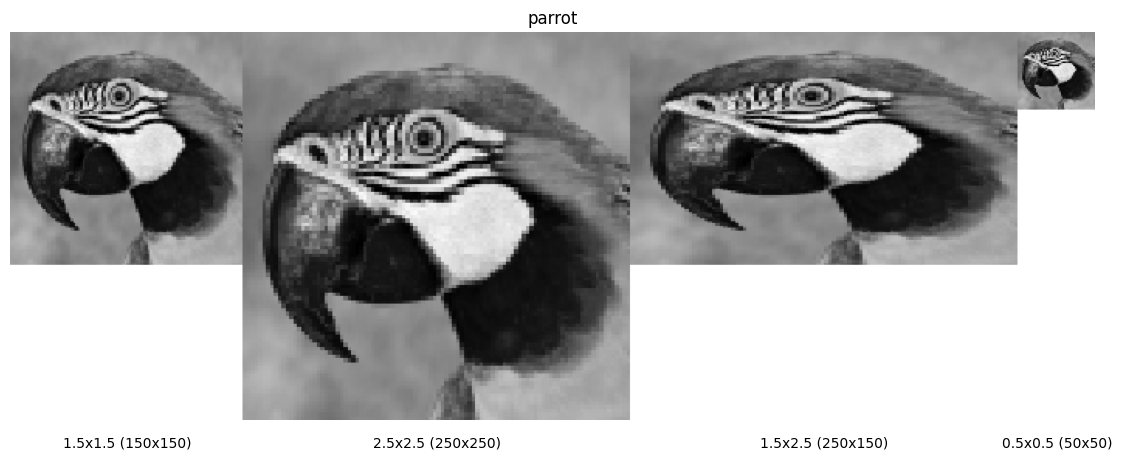

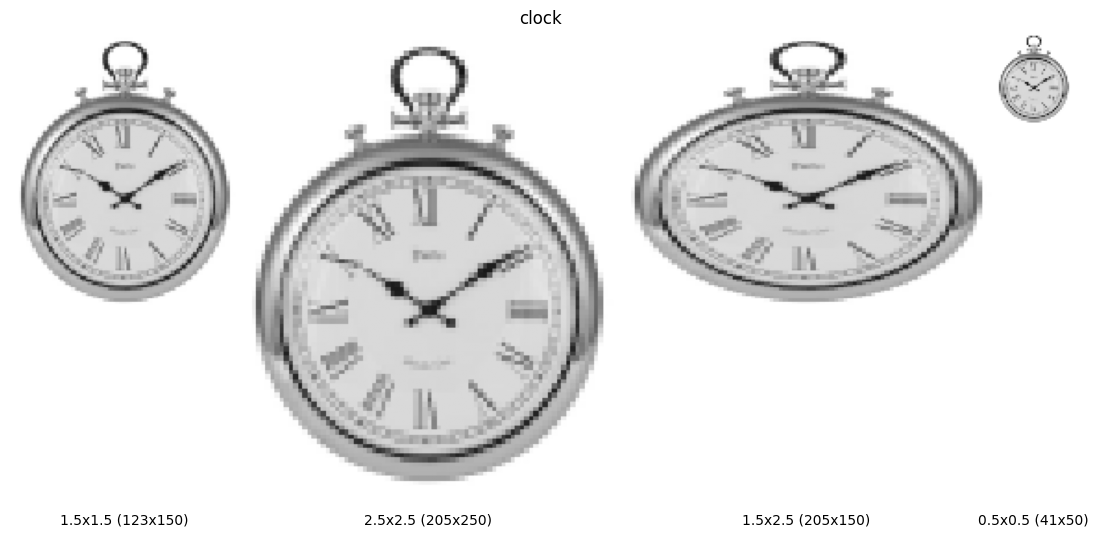

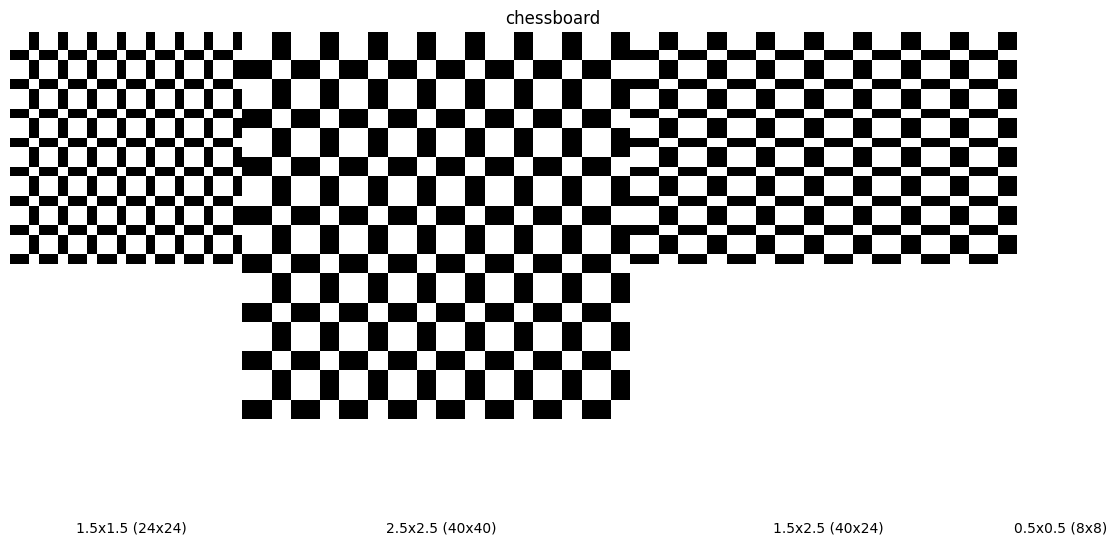

In [3]:
# TODO: Do samodzielnej implemetantacji

def interpolation_nearest_neighbour(image, scale_h, scale_w):
    (h, w) = image.shape[:2]
    output_h, output_w = int(round(h*scale_h)), int(round(w*scale_w))
    output_h, output_w = max(output_h, 1), max(output_w, 1)
    output_img = np.zeros((output_h, output_w))

    if image.ndim == 3:
        new_shape = (output_h, output_w, image.shape[2])
    else:
        new_shape = (output_h, output_w)
        
    output_img = np.zeros(new_shape, dtype=image.dtype)

    for h in range(output_h):
        for w in range(output_w):
            old_w_float = w / scale_w
            old_h_float = h / scale_h
            
            old_w = int(old_w_float)
            old_h = int(old_h_float)
            
            output_img[h, w] = image[old_h, old_w]
            
    return output_img

scale_cases = ((1.5, 1.5), (2.5, 2.5), (1.5, 2.5), (0.5, 0.5))

cases = {
    "parrot" : scale_cases,
    "clock" : scale_cases,
    "chessboard" : scale_cases
}

compare_cases(interpolation_nearest_neighbour, cases)


3. Testujemy stworzoną funkcję:
    * dla skali 1.5, 1.5 i obrazka *parrot*,
    * dla 2.5, 2.5 - tu może okazać się, że do kodu trzeba dopisać zabezpieczenie przed wyjściem poza zakres,
    * dla niejednakowych skal np. 1.5 i 2.5,
    * dla skal mniejszych od 1,
    * dla niesymetrycznego obrazka *clock*,
    * dla obrazka z szachownicą *chessboard*.

Uwaga: proszę dla powyższych przypadków przygotować osobne sekcje kodu - tak, aby wyświetlały się wszystkie rozważane przypadki.

Wykonana metoda jest bardzo prosta i szybka, ale wprowadza pewne niepożądane artefakty, w szczególnie źle odwzorowane są linie proste.
Z drugiej strony sprawdza się w pewnych nietypowych przypadkach.
Zostanie to zademonstrowane w dalszej części ćwiczenia.

## Interpolacja dwuliniowa

W praktyce, lepszym rozwiązaniem zwykle okazuje tzw. **interpolacja dwuliniowa** (ang. *bilinear interpolation*).
Wykorzystuje ona informację o czterech najbliższych sąsiadach do określenia nowej wartości piksela.

Jeśli przez $(i,j)$ oznaczymy współrzędne poszukiwanego piksela, a przez $I(i,j)$ jego jasność (składową w odcieniach szarości) to jego wartość można obliczyć wykorzystując równanie:
\begin{equation}
I(i,j) = a \cdot i + b \cdot j+ c \cdot i \cdot j + d
\end{equation}
gdzie: współczynniki $a,b,c,d$ można wyliczyć na podstawie czterech najbliższych sąsiadów.

![Ilustracja dwuliniowej](https://raw.githubusercontent.com/vision-agh/poc_sw/master/05_Resolution/img/interABCD.png)

Prześledźmy to na przykładzie z powyższego rysunku.
Niech współrzędne poszczególnych punktów to $A = (j_1,i_1)$, $B = (j_1,i_2)$, $ C= (j_2,i_2)$ oraz $D = (j_2,i_1)$.
W pierwszej kolejności dokonujemy interpolacji wartości w punktach $AB$ i $CD$ -- czyli poziomo.
Wychodząc od równania prostej otrzymujemy:

\begin{equation}
f(AB) \approx \frac{i_2 - i}{i_2-i_1}f(A) + \frac{i - i_1}{i_2-i_1}f(B)
\end{equation}

\begin{equation}
f(CD) \approx \frac{i_2 - i}{i_2-i_1}f(D) + \frac{i - i_1}{i_2-i_1}f(C)
\end{equation}

Następnie wykonujemy analogiczną interpolację w pionie:
\begin{equation}
f(ABCD) \approx \frac{j_2 - j}{j_2-j_1}f(AB) + \frac{j - j_1}{j_2-j_1}f(CD)
\end{equation}

Łącząc powyższe równania otrzymujemy:
\begin{equation}
f(ABCD) \approx \frac{1}{(i_2 - i_1)(j_2-j_1)} ( f(A)(i_2-i)(j_2 - y) + f(B)(i-i_1)(j_2 - j) \\ + f(C)(i-i_1)(j-j_1) + f(D)(i_2-i)(j-j_1))
\end{equation}
gdzie zapis $f(X)$ oznacza wartość piksela w punkcie $X$.

Rozważania można uprościć przyjmując, że narożniki rozpatrywanego kwadratu mają następujące współrzędne: $A = (0,0)$, $B = (0,1)$, $ C= (1,1)$ oraz $D = (1,0)$.
Wtedy powyższe równanie można zapisać:
\begin{equation}
f(ABCD) \approx f(A)(1-i)(1-j) + f(B)i(1-j) + f(C)ij + f(D)(1-i)j
\end{equation}

lub macierzowo:
\begin{equation}
f(ABCD) \approx \begin{bmatrix}1 - i & i \end{bmatrix} \begin{bmatrix} f(A) & f(D) \\\\ f(B) & f(C)  \end{bmatrix}   \begin{bmatrix} 1-j \\\\ j  \end{bmatrix}
\end{equation}

Uwaga.
Nieco wbrew nazwie interpolacja dwuliniowa nie jest operacją liniową.
W złożeniu dwóch operacji liniowych pojawia się człon $xy$.

Warto dodać, że kolejny ``poziom wtajemniczenia'' to **interpolacja dwusześcienna** (ang. *bicubic interpolation*).
Dana jest ona wzorem:
\begin{equation}
I(i,j) = \sum_{i=0}^{3} \sum_{j=0}^{3} a_{ij} x^i y^j
\end{equation}
Jej implementacja stanowi zadanie domowe do bieżącego ćwiczenia.

Trzy powyżej przedstawione metody bynajmniej nie wyczerpują tematu.
Wystarczy choćby otworzyć stronę [wiki o skalowaniu](https://en.wikipedia.org/wiki/Image_scaling), by zobaczyć, że metod jest dużo więcej.



Wykorzystując powyższe równania zaimplementuj interpolację dwuliniową:
* dobrym punktem wyjścia będzie stworzona funkcja do interpolacji metodą najbliższego sąsiada,
* początek powinien być identyczny,
* różnice rozpoczynają się w momencie obliczenia współrzędnych nowego piksela,
* jeśli chcemy zastosować opisane powyżej wzory (w wariancie uproszczonym), to musimy wyliczyć współrzędne punktów $A,B,C,D$,
* w pierwszym kroku obliczamy współrzędne $A$ tj. $(0,0)$ - należy do tego wykorzystać funkcję *floor* (np. $i_1 = floor(i / h_{scale})$).
  Proszę ten krok odnieść do przedstawionego rysunku poglądowego,
* obliczenie współrzędnych $B,C,D$ jest już proste i sprowadza się do operacji `+1`,
* potrzebujemy jeszcze część ułamkową współrzędnych punktu $ABCD$ tj. $(i,j)$ - od ilorazu $i/h_{scale}$ należy odjąć wartość $i_1$
* wykorzystując wyznaczone współrzędne, należy pobrać wartości jasności w punktach $A,B,C,D$, tj. $f(A),f(B),f(C),f(D)$, podstawić do odpowiedniego równania i wykonać interpolację.

  Uwagi:
* Tworzenie macierzy *np.array*, mnożenie macierzy *np.dot*. Przy tworzeniu macierzy proszę zwrócić uwagę na niezbędne nawiasy kwadratowe.
* Przy próbie uruchomienia kodu pewnie okaże się, że wystąpi przekroczenie zakresu - należy dodać stosowne zabezpiczenie.

Proszę dla interpolacji dwuliniowej wykonać takie same eksperymenty, jak dla  najbliższego sąsiada.




In [4]:
# TODO: Do samodzielnej implemetantacji

def interpolation_bilinear(image, scale_h, scale_w):
    h, w = image.shape[:2]
    output_h, output_w = int(round(h * scale_h)), int(round(w * scale_w))
    output_img = np.zeros((output_h, output_w), dtype=image.dtype)

    for i in range(output_h):
        for j in range(output_w):
            y = i / scale_h
            x = j / scale_w

            y1 = int(np.floor(y))
            x1 = int(np.floor(x))
            y2 = min(y1 + 1, h - 1)
            x2 = min(x1 + 1, w - 1)

            dy = y - y1
            dx = x - x1

            A = image[y1, x1]
            B = image[y1, x2]
            C = image[y2, x1]
            D = image[y2, x2]

            value = (
                A * (1 - dx) * (1 - dy) +
                B * dx * (1 - dy) +
                C * (1 - dx) * dy +
                D * dx * dy
            )

            output_img[i, j] = np.clip(value, 0, 255)

    return output_img


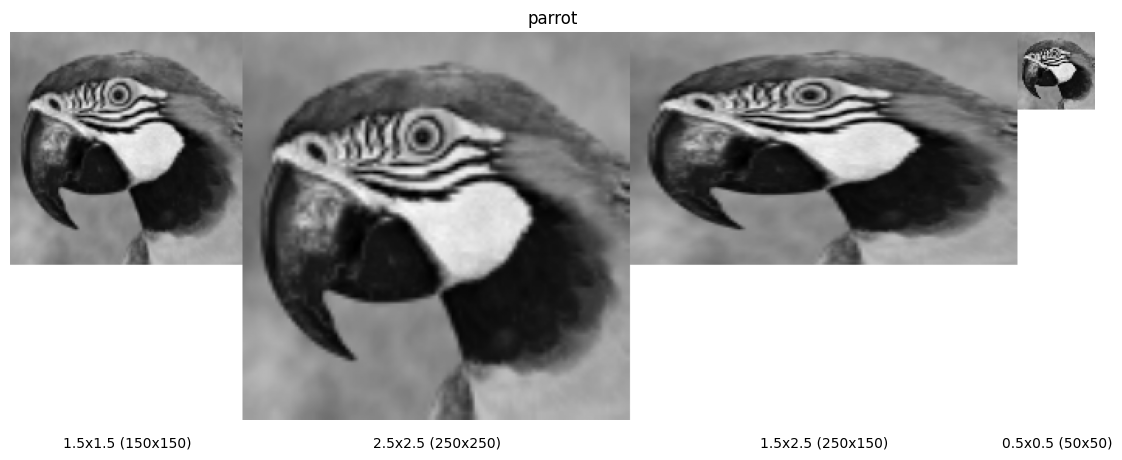

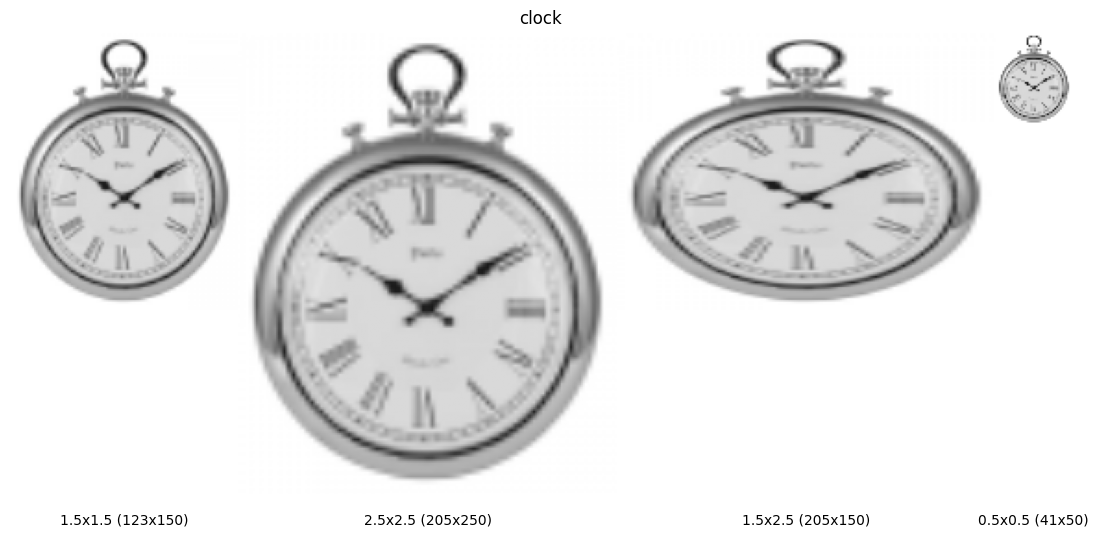

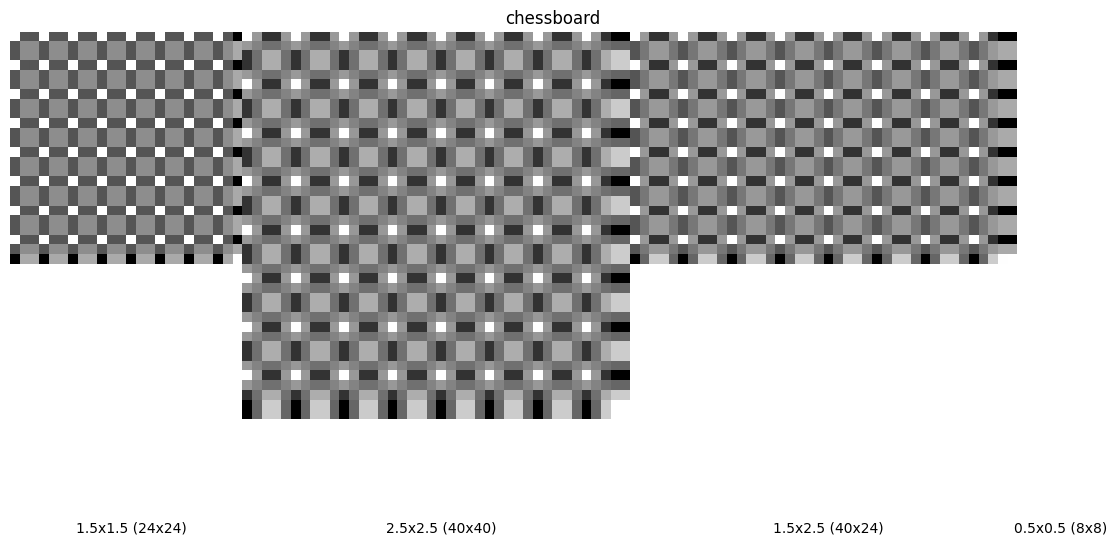

In [5]:
#TODO Do samodzielnej implementacji

scale_cases = ((1.5, 1.5), (2.5, 2.5), (1.5, 2.5), (0.5, 0.5))

cases = {
    "parrot" : scale_cases,
    "clock" : scale_cases,
    "chessboard" : scale_cases
}

compare_cases(interpolation_bilinear, cases)

## Intepolacja w OpenCV

W OpenCV dostępna jest funkcja `resize`, która służy do zmiany rozmiaru obrazka.
Składnia jest następująca `dst = cv2.resize(src, dsize[, dst[, fx[, fy[, interpolation]]]] )`, gdzie `dst` to obraz wynikowy, `src` obraz źródłowy, `dsize` rozmiar docelowy (ew. można podać współczynniki skalowania dla poszczególnych osi: `fx,fy`), `interpolation` metoda interpolacji.
Metod podstawowych dostępnych jest 5:
- najbliższego sąsiada - ` cv2.INTER_NEAREST`,
- dwuliniowa - ` cv2.INTER_LINEAR`,
- dwukubiczna - ` cv2.INTER_CUBIC`,
- *area* - ` cv2.INTER_AREA`,
- *lanczos4* - ` cv2.INTER_LANCZOS4`.

Przeprowadzimy następujący eksperyment: obraz (o większej niż dotąd rozdzielczości) przeskalujemy każdą z metod -- zwiększymy i zmniejszymy jego rozdzielczość. Dodamy też pomiar czasu realizacji obliczeń.

Proszę stworzyć funkcję, która jako argumenty przyjmuje obraz oraz dwa współczynniki skalujące, a wewnątrz przeprowadzone zostaną interpolacje, pomiar czasu oraz wizualizacja (można wypisać czas w tytule rysunku).

Pomiar czasu:
```{python}
from timeit import default_timer as timer
start = timer()
# ...
end = timer()
print(end - start)
```

Wykonaj eksperyment dla kilku różnych skal, przeanalizuj czasy obliczeń.

In [6]:
from timeit import default_timer as timer
import numpy as np
import matplotlib.pyplot as plt
import cv2

def compare_opencv_interpolations(image, scale_h, scale_w):
    methods = {
        "Nearest (cv2.INTER_NEAREST)": cv2.INTER_NEAREST,
        "Linear (cv2.INTER_LINEAR)": cv2.INTER_LINEAR,
        "Cubic (cv2.INTER_CUBIC)": cv2.INTER_CUBIC,
        "Area (cv2.INTER_AREA)": cv2.INTER_AREA,
        "Lanczos4 (cv2.INTER_LANCZOS4)": cv2.INTER_LANCZOS4
    }

    results = []
    titles = []

    results.append(image)
    titles.append("Oryginał")

    for name, method in methods.items():
        start = timer()
        resized = cv2.resize(image, None, fx=scale_w, fy=scale_h, interpolation=method)
        end = timer()

        results.append(resized)

        print(f"Method: {name}, time: {end - start:.8f}")

    total_width = sum(r.shape[1] for r in results)
    max_height = max(r.shape[0] for r in results)

    canvas = np.ones((max_height + 40, total_width), dtype=np.uint8) * 255

    current_x = 0
    for res, title in zip(results, titles):
        h, w = res.shape
        canvas[:h, current_x:current_x + w] = res
        plt.text(current_x + w/2, max_height + 20, title, ha='center', va='top', fontsize=8)
        current_x += w

    plt.close('all')
    plt.figure(figsize=(18, 6))
    plt.imshow(canvas, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')
    plt.title(f"Porównanie metod interpolacji (skala {scale_h}x{scale_w})")
    plt.show()


Method: Nearest (cv2.INTER_NEAREST), time: 0.00180860
Method: Linear (cv2.INTER_LINEAR), time: 0.00080300
Method: Cubic (cv2.INTER_CUBIC), time: 0.00509470
Method: Area (cv2.INTER_AREA), time: 0.00003310
Method: Lanczos4 (cv2.INTER_LANCZOS4), time: 0.00478820


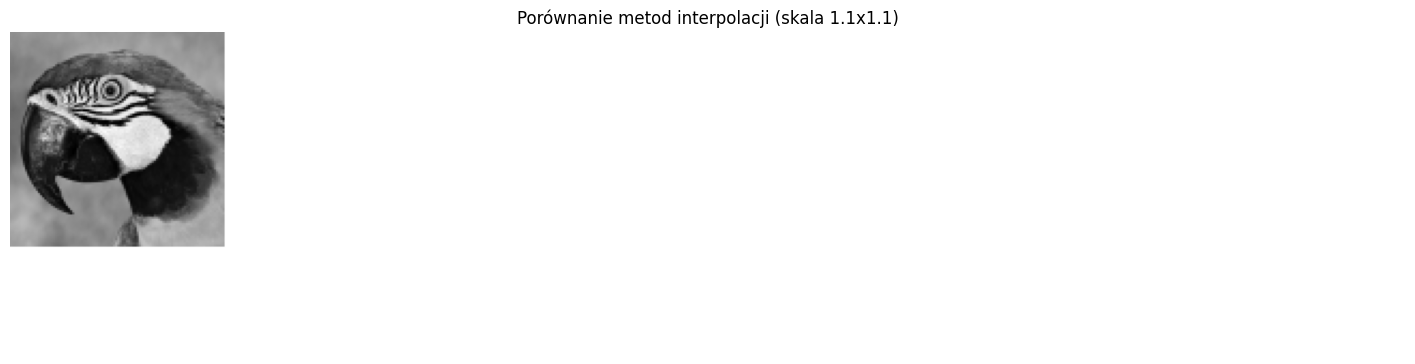

Method: Nearest (cv2.INTER_NEAREST), time: 0.00009110
Method: Linear (cv2.INTER_LINEAR), time: 0.00001980
Method: Cubic (cv2.INTER_CUBIC), time: 0.00004420
Method: Area (cv2.INTER_AREA), time: 0.00004600
Method: Lanczos4 (cv2.INTER_LANCZOS4), time: 0.00010220


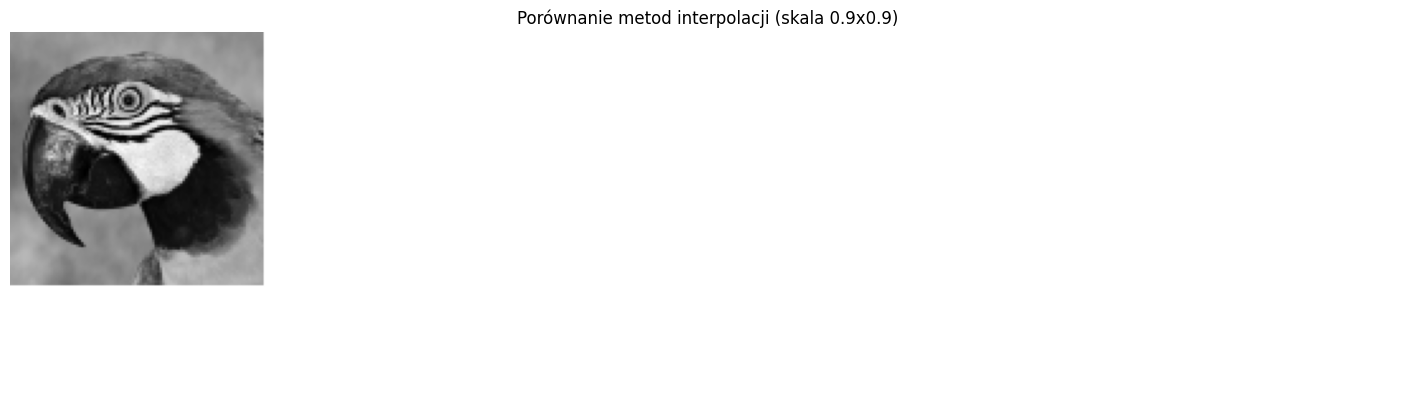

In [7]:

compare_opencv_interpolations(images["parrot"], 1.1, 1.1)
compare_opencv_interpolations(images["parrot"], 0.9, 0.9)


## Rozdzielczość (dpi)

Omówioną wcześniej rozdzielczość przestrzenną (rozmiar) należy utożsamiać z rozmiarem macierzy w której zapisany jest obraz.
W tym ujęciu rozmiar pojedynczego piksela nie ma specjalnego znaczenia.
Problem pojawia się, kiedy obraz trzeba wyświetlić lub wydrukować.
Wtedy pojedynczy piksel staje się ,,obiektem fizycznym'' i musi mieć swój rozmiar (wysokość/szerokość/powierzchnię).

Parametr dpi (ang. *dots per inch*) określa liczbę kropek (pikseli), która mieści się na jednym calu (25,4 mm) długości/szerokości.
Dopiero kombinacja rozmiaru i rozdzielczości określa nam rzeczywisty rozmiar obrazu jaki uzyskamy na wydruku.

Dpi staje się istotne w przypadku drukowania, gdyż wyświetlanie na monitorze odbywa się zazwyczaj 1 piksel obrazka = 1 piksel na monitorze (w przypadku maksymalnej rozdzielczości wspieranej przez monitor), ew. następuje automatyczne skalowanie.

Wpływ rozdzielczości można zademonstrować w następujący sposób:
- wczytaj obraz *lena.bmp*.  Ma on rozmiar $512 \times 512$.
- wykorzystując funkcję `imresize` stwórz obrazy o rozmiarach $256 \times 256$, $128 \times 128$, $64 \times 64$ - metoda interpolacji jest w tym wypadku mniej istotna.
- wyświetl obrazy wymuszając zachowanie na ekranie wejściowej rozdzielczości $512 \times 512$. W przypadku biblioteki *matplotlib* ta funkcjonalność jest domyślna.

Proszę zaobserwować co dzieję się z obrazkiem.

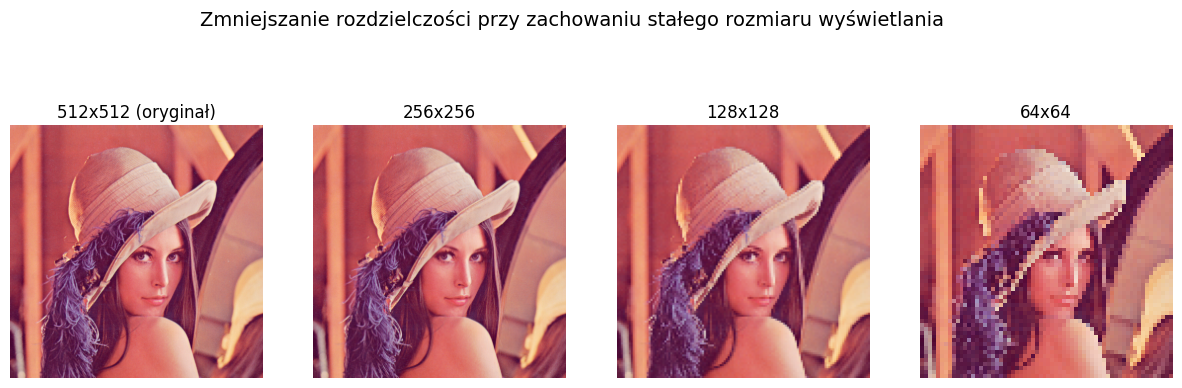

In [8]:
#TODO Porównanie

url = "https://raw.githubusercontent.com/vision-agh/poc_sw/master/03_Histogram/lenaRGB.bmp"
filename = "lenaRGB.bmp"

if not os.path.exists(filename):
    r = requests.get(url, allow_redirects=True)
    open(filename, 'wb').write(r.content)

lena = cv2.imread(filename)
lena = cv2.cvtColor(lena, cv2.COLOR_BGR2RGB)

sizes = [256, 128, 64]
resized_images = [cv2.resize(lena, (s, s), interpolation=cv2.INTER_LINEAR) for s in sizes]

titles = ["512x512 (oryginał)"] + [f"{s}x{s}" for s in sizes]
images_to_show = [lena] + resized_images

plt.figure(figsize=(15, 5))
for i, (img, title) in enumerate(zip(images_to_show, titles)):
    plt.subplot(1, len(images_to_show), i + 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
plt.suptitle("Zmniejszanie rozdzielczości przy zachowaniu stałego rozmiaru wyświetlania", fontsize=14)
plt.show()


## Liczba poziomów jasności

Dla obrazów w skali szarości pojedynczy piksel zwykle zapisuje się na 8 bitach, co daje 256 rozróżnialnych poziomów szarości.
Dla większości zastosowań wartość ta jest wystarczająca (choć są kamery o wyjścu 12 lub 16 bitów).
Jednak oko ludzkie nie potrafi rozróżnić wszystkich 256 poziomów jasności (jest za mało czułe).
Zazwyczaj człowiek rozróżnia 20-30 poziomów szarości (to ile i jakie dokładnie rozróżnia, zależy od konkretnego oświetlenia sceny i cech osobniczych).

W poniższych krokach zademonstrujemy omówione zjawisko:
- wczytaj (użyj) obrazu _lena_,
- wykorzystując znaną funkcję `normalize` zmień liczbę poziomów szarości z 0-255 na:
    * 0-31
    * 0-15
    * 0-7
    * 0-3
    * 0-1 (binaryzacja)
- rezultaty wyświetl na wspólnym rysunku.

Podpowiedzi:
- trzeba przygotować tablice na obrazki np, `I_31 = np.zeros(I.shape,'uint8')`,
- prawidłowe użycie funkcji normalize `cv2.normalize(I,I_31,0,31,cv2.NORM_MINMAX)`,
- przykładowe wyświetlanie `axsHist[0,1].imshow(I, 'gray', vmin=0, vmax=31)`.

Czy rezultaty eksperymentu pasują do teorii o rozpoznawaniu przez człowieka ograniczonego zakresu poziomów jasności?
Wizualne porównanie których obrazów o tym świadczy?

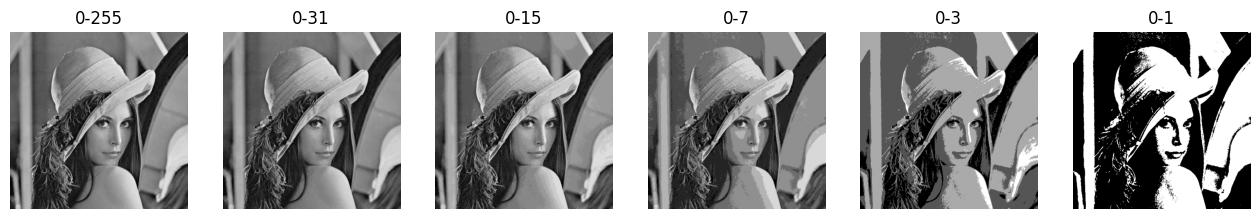

In [9]:
#TODO Do samodzielnej realizacji

I = cv2.imread('lenaRGB.bmp', cv2.IMREAD_GRAYSCALE)

levels = [255, 31, 15, 7, 3, 1]
images = []

for L in levels:
    I_new = np.zeros(I.shape, 'uint8')
    cv2.normalize(I, I_new, 0, L, cv2.NORM_MINMAX)
    I_display = (I_new * (255 // L)).astype('uint8')
    images.append(I_display)

fig, axs = plt.subplots(1, len(levels), figsize=(16, 4))
for i, (img, L) in enumerate(zip(images, levels)):
    axs[i].imshow(img, cmap='gray', vmin=0, vmax=255)
    axs[i].set_title(f"0-{L}")
    axs[i].axis('off')
plt.show()